In [34]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.semi_supervised import LabelPropagation, LabelSpreading, SelfTrainingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.impute import SimpleImputer

In [35]:
data = pd.read_csv('PD_complete(in).csv', delimiter=';')

In [ ]:
# anonymizing column names
import pandas as pd

# Rename columns to Feature1, Feature2, etc.
data.columns = [f'Feature{i+1}' for i in range(len(data.columns))]

#show the new column names
print(data.columns)

Index(['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5', 'Feature6',
       'Feature7', 'Feature8', 'Feature9', 'Feature10', 'Feature11',
       'Feature12', 'Feature13', 'Feature14'],
      dtype='object')


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature1   376 non-null    int64  
 1   Feature2   376 non-null    int64  
 2   Feature3   376 non-null    int64  
 3   Feature4   376 non-null    int64  
 4   Feature5   376 non-null    int64  
 5   Feature6   376 non-null    int64  
 6   Feature7   376 non-null    int64  
 7   Feature8   376 non-null    int64  
 8   Feature9   376 non-null    float64
 9   Feature10  376 non-null    object 
 10  Feature11  376 non-null    object 
 11  Feature12  376 non-null    object 
 12  Feature13  376 non-null    object 
 13  Feature14  376 non-null    object 
dtypes: float64(1), int64(8), object(5)
memory usage: 41.3+ KB


In [36]:
#data

In [ ]:
target_column ='Feature13'     

In [8]:
data.isnull().sum()

Feature1     0
Feature2     0
Feature3     0
Feature4     0
Feature5     0
Feature6     0
Feature7     0
Feature8     0
Feature9     0
Feature10    0
Feature11    0
Feature12    0
Feature13    0
Feature14    0
dtype: int64

#### Drop rows when target column is Missing connection types

In [ ]:
data = data[data['Feature13'] != 'Missing connection types'] 
data = data[data['Feature11']!='Übergangsmuffe XLPE auf Papier-Masse'] 

In [10]:
# Covert to numeric
data[target_column] = pd.to_numeric(data[target_column], errors='coerce')

In [11]:
# find out columns of object dtypes
object_cols = data.select_dtypes(include=["object"]).columns
# get distinct values
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'Feature10' column:
['01. Aug' '01. Jul' '01. Mrz' '1.0' '01. Mai']
------------------------------
Distinct values in 'Feature11' column:
['VPE-Kabel' 'Papier-Masse-Kabel' 'Übergangsmuffe Papier-Masse auf (V)PE'
 'Übergangsmuffe (V)PE auf Papier-Masse' 'Endverschluss'
 'Übergangsmuffe Papier-Masse auf Papier-Masse']
------------------------------
Distinct values in 'Feature12' column:
['Linie' 'Glocke symmetrisch' 'Bar' 'Glocke links' 'Glocke rechts']
------------------------------
Distinct values in 'Feature14' column:
['XLPE' 'Papier-Masse' 'Mischkabel']
------------------------------


In [12]:
enc = LabelEncoder()
for col in object_cols:
    data[col] = enc.fit_transform(data[col])

In [13]:
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'Feature10' column:
[0 1 3 4 2]
------------------------------
Distinct values in 'Feature11' column:
[2 1 4 3 0 5]
------------------------------
Distinct values in 'Feature12' column:
[4 3 0 1 2]
------------------------------
Distinct values in 'Feature14' column:
[2 1 0]
------------------------------


           Feature5  Feature6  Feature7  Feature8  Feature9  Feature10  \
Feature5   1.000000 -0.040713 -0.031883 -0.038485  0.050225   0.091829   
Feature6  -0.040713  1.000000  0.212611 -0.287546 -0.228531  -0.567147   
Feature7  -0.031883  0.212611  1.000000  0.135080 -0.162202  -0.006042   
Feature8  -0.038485 -0.287546  0.135080  1.000000 -0.104390   0.337474   
Feature9   0.050225 -0.228531 -0.162202 -0.104390  1.000000  -0.033049   
Feature10  0.091829 -0.567147 -0.006042  0.337474 -0.033049   1.000000   
Feature11 -0.005508  0.122308 -0.066390 -0.008454  0.168863  -0.176032   
Feature12 -0.019229  0.221162 -0.128063 -0.047125  0.145216  -0.193420   
Feature13 -0.060055 -0.011970 -0.119509  0.101877  0.196952  -0.013546   
Feature14 -0.025595  0.277676  0.231345 -0.243605 -0.138574  -0.090666   

           Feature11  Feature12  Feature13  Feature14  
Feature5   -0.005508  -0.019229  -0.060055  -0.025595  
Feature6    0.122308   0.221162  -0.011970   0.277676  
Feature7   -0.066

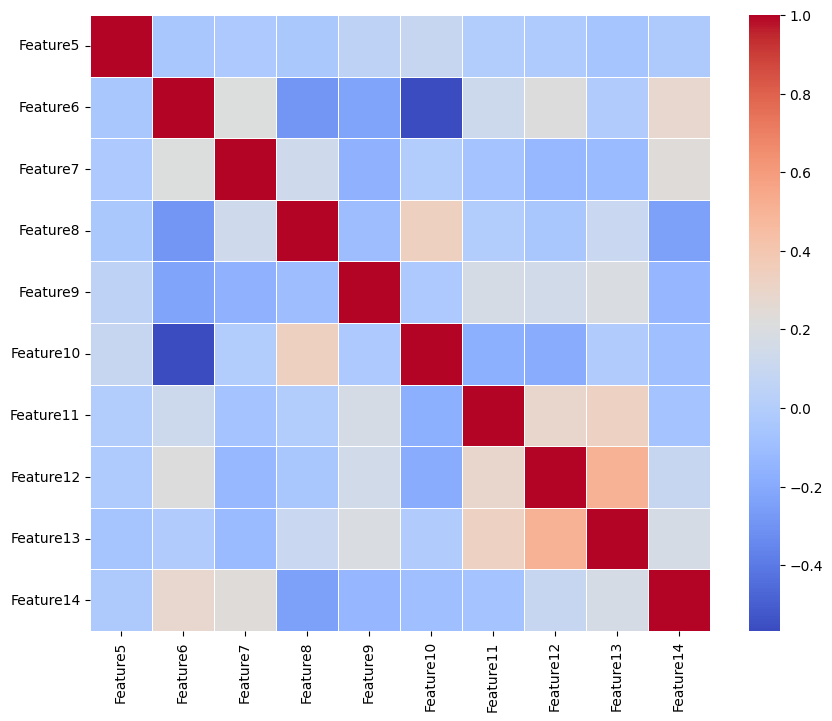

In [ ]:
#dropping id columns
data_for_analysis = data.drop(['Feature1', 'Feature3', 'Feature4','Feature2'], axis=1)
correlation_matrix = data_for_analysis.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

In [37]:
#data_for_analysis

In [ ]:
data_for_analysis = data_for_analysis[(data_for_analysis['Feature9'] != 43000) & (data_for_analysis['Feature9'] != 46000)]  
data_for_analysis = data_for_analysis[data_for_analysis['Feature8'] != 5063]  

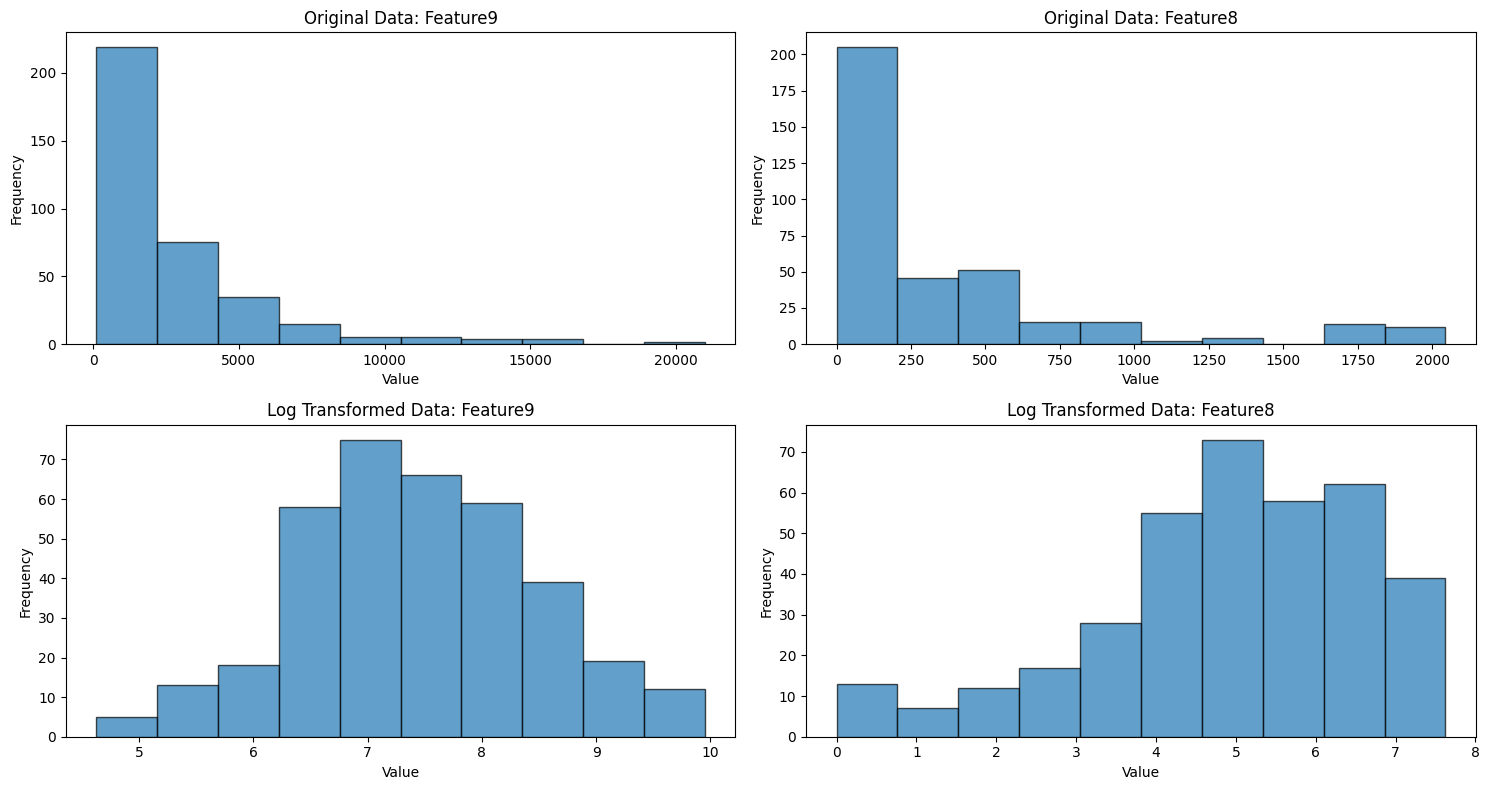

In [17]:
# Manually specify the numerical features
numerical_features = ['Feature9', 'Feature8']  # List of numerical columns to include
selected_data = data_for_analysis[numerical_features]

# Apply log transformation (add 1 to avoid log(0) issues)
log_transformed = selected_data.apply(lambda x: np.log1p(x))

# Plotting
fig, axes = plt.subplots(2, len(selected_data.columns), figsize=(15, 8))

# Titles for each transformation
titles = ["Original Data", "Log Transformed Data"]

# Loop through features and transformations
for i, col in enumerate(selected_data.columns):
    # Original Data
    axes[0, i].hist(selected_data[col], bins=10, edgecolor='k', alpha=0.7)
    axes[0, i].set_title(f"{titles[0]}: {col}")
    axes[0, i].set_xlabel("Value")
    axes[0, i].set_ylabel("Frequency")
    
    # Log Transformed Data
    axes[1, i].hist(log_transformed[col], bins=10, edgecolor='k', alpha=0.7)
    axes[1, i].set_title(f"{titles[1]}: {col}")
    axes[1, i].set_xlabel("Value")
    axes[1, i].set_ylabel("Frequency")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [18]:
data_for_analysis[numerical_features] = log_transformed

In [19]:
# Get input/output dataframes
y = data_for_analysis[target_column]
x = data_for_analysis.drop([target_column],axis=1)

In [20]:
# Standard deviation before scaling
x.std()

Feature5     0.814994
Feature6     3.013265
Feature7     1.484119
Feature8     1.693108
Feature9     1.004874
Feature10    1.059984
Feature11    0.990323
Feature12    1.541608
Feature14    0.660661
dtype: float64

In [21]:
# apply scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(x)
x_standardized = pd.DataFrame(scaled_features, columns=x.columns)

In [23]:
# standard deviation after scaling
x_standardized.std()

Feature5     1.001376
Feature6     1.001376
Feature7     1.001376
Feature8     1.001376
Feature9     1.001376
Feature10    1.001376
Feature11    1.001376
Feature12    1.001376
Feature14    1.001376
dtype: float64

In [24]:
x_standardized.columns

Index(['Feature5', 'Feature6', 'Feature7', 'Feature8', 'Feature9', 'Feature10',
       'Feature11', 'Feature12', 'Feature14'],
      dtype='object')

#### Semi-Supervised Learning


In [25]:
# Convert target to semi-supervised format (-1 for unlabeled data)
def create_semi_supervised_labels(y, label_percentage):
    np.random.seed(30)
    labeled_indices = np.random.choice(len(y), size=int(len(y) * label_percentage), replace=False)
    y_semi = np.full_like(y, fill_value=-1, dtype=int)
    y_semi[labeled_indices] = y[labeled_indices]
    return y_semi

### Let's do a grid search for both models with weighted F1-score

In [26]:
def run_grid_search(X, y, model_type):
    model = LabelPropagation() if model_type == 'LabelPropagation' else LabelSpreading()

    param_grid = {
        'kernel': ['rbf', 'knn'],
        'gamma': [10, 20, 50, 100, 150]
    }

    if model_type == 'LabelSpreading':  # Only LabelSpreading supports `alpha`
        param_grid['alpha'] = [0.1, 0.3, 0.5, 0.8]

    # Let's define scoring metrics for grid search
    scoring = {'accuracy': 'accuracy', 'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=0)}

    grid = GridSearchCV(model, param_grid, scoring=scoring, refit='accuracy', cv=3, n_jobs=-1)

    # Filter out unlabeled data points
    labeled_indices = y != -1
    X_labeled, y_labeled = X[labeled_indices], y[labeled_indices]

    grid.fit(X_labeled, y_labeled)

    # Now save the best estimator and parameters
    best_model = grid.best_estimator_
    best_params = grid.best_params_
    best_accuracy = grid.best_score_

    return best_params, best_accuracy, best_model

##### Using Optuna

In [27]:
def run_optuna_optimization(X, y, model_type, n_trials=20):
    # Filter labeled data
    labeled_indices = y != -1
    X_labeled, y_labeled = X[labeled_indices], y[labeled_indices]

    def objective(trial):
        if model_type in ['LabelPropagation', 'LabelSpreading']:
            kernel = trial.suggest_categorical('kernel', ['rbf', 'knn'])
            gamma = trial.suggest_categorical('gamma', [10, 20, 50, 100])
            if model_type == 'LabelPropagation':
                model = LabelPropagation(kernel=kernel, gamma=gamma)
            else:
                alpha = trial.suggest_categorical('alpha', [0.1, 0.3, 0.5, 0.8])
                model = LabelSpreading(kernel=kernel, gamma=gamma, alpha=alpha)
        else:  # Self-Training: using default SVC as base estimator
            base_estimator = SVC(probability=True, gamma='scale')
            model = SelfTrainingClassifier(base_estimator)

        # Evaluate using 3-fold cross-validation on the labeled data
        scores = cross_val_score(model, X_labeled, y_labeled, cv=3, scoring='accuracy', n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    best_params = study.best_trial.params
    best_score = study.best_value

    # Build the best model using the best parameters.
    if model_type in ['LabelPropagation', 'LabelSpreading']:
        if model_type == 'LabelPropagation':
            best_model = LabelPropagation(**best_params)
        else:
            best_model = LabelSpreading(**best_params)
    else:
        best_model = SelfTrainingClassifier(SVC(probability=True, gamma='scale'))

    # Train the best model on the full labeled data.
    best_model.fit(X_labeled, y_labeled)
    return best_params, best_score, best_model

### Progressive Validation 

labeled_percentages = [0.1, 0.2, 0.4, 0.6, 0.8]
results = []

for perc in labeled_percentages:
    y_semi = create_semi_supervised_labels(y.to_numpy(), perc)

    for model_type in ['LabelPropagation', 'LabelSpreading']:
        best_params, best_accuracy, best_model = run_grid_search(x_standardized.to_numpy(), y_semi, model_type)

        # Predict on the entire dataset (both labeled and unlabeled data)
        y_pred = best_model.predict(x_standardized.to_numpy())  # Predict all data points

        # Separate labeled and unlabeled data points
        labeled_indices = y_semi != -1
        y_true = y.to_numpy()  # True values (including labeled and unlabeled)
        
        # Calculate the weighted F1-score on the labeled data only (to compare against true labels)
        weighted_f1 = f1_score(y_true[labeled_indices], y_pred[labeled_indices], average='weighted', zero_division=0)

        results.append({
            'Model': model_type, 
            'Labeled %': perc, 
            'Best Params': best_params, 
            'Best Accuracy': best_accuracy,
            'Weighted F1 Score': weighted_f1
        })

# Convert results to DataFrame to display
results_df = pd.DataFrame(results)
print("Labeled Data Requirement Results:\n", results_df)

In [28]:
labeled_percentages = [0.1, 0.2, 0.4, 0.6, 0.8]
results = []

for perc in labeled_percentages:
    y_semi = create_semi_supervised_labels(y.to_numpy(), perc)
    
    for model_type in ['LabelPropagation', 'LabelSpreading', 'Self-Training']:
        best_params, best_accuracy, best_model = run_optuna_optimization(x_standardized.to_numpy(), y_semi, model_type, n_trials=20)
        
        # Predict on the entire dataset (both labeled and unlabeled data)
        y_pred = best_model.predict(x_standardized.to_numpy())
        
        # Only evaluate metrics on the originally labeled data
        labeled_indices = y_semi != -1
        y_true = y.to_numpy()
        weighted_f1 = f1_score(y_true[labeled_indices], y_pred[labeled_indices], average='weighted', zero_division=0)
        
        results.append({
            'Model': model_type,
            'Labeled %': perc,
            'Best Params': best_params,
            'Best Accuracy': best_accuracy,
            'Weighted F1 Score': weighted_f1
        })

# Convert results to DataFrame and display
results_df = pd.DataFrame(results)
print("Labeled Data Requirement Results:\n", results_df)

[I 2025-05-07 17:10:49,884] A new study created in memory with name: no-name-f877056e-94dd-44c8-bc62-3b848c798a75
d:\master Automation & IT\winter semester 2024\case study Bartz\.venv\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
[I 2025-05-07 17:10:51,745] Trial 0 finished with value: 0.5833333333333334 and parameters: {'kernel': 'rbf', 'gamma': 20}. Best is trial 0 with value: 0.5833333333333334.
d:\master Automation & IT\winter semester 2024\case study Bartz\.venv\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
[I 2025-05-07 17:10:52,846] Trial 1 finished with value: 0.6666666666666666 and parameters: {'kernel': 'knn', 'gamma': 50}. Best is trial 0 with value: 0.5833333333333334.
d:\master Automation & IT\winter semester 2024\case study Bartz\

Labeled Data Requirement Results:
                Model  Labeled %  \
0   LabelPropagation        0.1   
1     LabelSpreading        0.1   
2      Self-Training        0.1   
3   LabelPropagation        0.2   
4     LabelSpreading        0.2   
5      Self-Training        0.2   
6   LabelPropagation        0.4   
7     LabelSpreading        0.4   
8      Self-Training        0.4   
9   LabelPropagation        0.6   
10    LabelSpreading        0.6   
11     Self-Training        0.6   
12  LabelPropagation        0.8   
13    LabelSpreading        0.8   
14     Self-Training        0.8   

                                      Best Params  Best Accuracy  \
0                  {'kernel': 'rbf', 'gamma': 20}       0.583333   
1    {'kernel': 'rbf', 'gamma': 50, 'alpha': 0.8}       0.555556   
2                                              {}       0.638889   
3                  {'kernel': 'knn', 'gamma': 10}       0.583333   
4    {'kernel': 'knn', 'gamma': 20, 'alpha': 0.3}       0.555556

#### Let's plot now

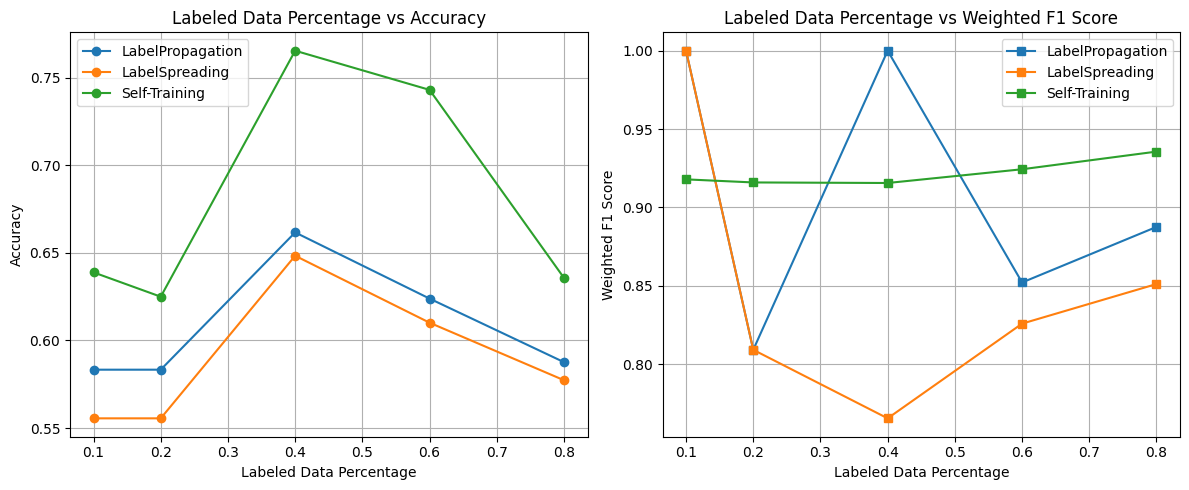

In [29]:
plt.figure(figsize=(12, 5))

# Subplot 1: Accuracy vs Labeled Percentage
plt.subplot(1, 2, 1)
for model_type in ['LabelPropagation', 'LabelSpreading', 'Self-Training']:
    subset = results_df[results_df['Model'] == model_type]
    plt.plot(subset['Labeled %'], subset['Best Accuracy'], marker='o', label=f"{model_type}")

plt.title('Labeled Data Percentage vs Accuracy')
plt.xlabel('Labeled Data Percentage')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Subplot 2: Weighted F1 Score vs Labeled Percentage
plt.subplot(1, 2, 2)
for model_type in ['LabelPropagation', 'LabelSpreading', 'Self-Training']:
    subset = results_df[results_df['Model'] == model_type]
    plt.plot(subset['Labeled %'], subset['Weighted F1 Score'], marker='s', label=f"{model_type}")

plt.title('Labeled Data Percentage vs Weighted F1 Score')
plt.xlabel('Labeled Data Percentage')
plt.ylabel('Weighted F1 Score')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Missing Data

In [30]:
def add_missing_data(X, missing_percentage, column):
    X_missing = X.copy()
    np.random.seed(42)
    total_values = X_missing[column].shape[0]
    n_missing = int(total_values * missing_percentage)
    missing_indices = np.random.choice(X_missing.index, n_missing, replace=False)
    X_missing.loc[missing_indices, column] = np.nan
    return X_missing

In [31]:
def create_semi_supervised_labels(y, label_percentage):
    np.random.seed(42)
    y_semi = y.copy()
    total_labels = len(y_semi)
    n_labeled = int(total_labels * label_percentage)
    labeled_indices = np.random.choice(np.arange(total_labels), n_labeled, replace=False)
    y_semi[:] = -1  # Mark all as unlabeled
    y_semi[labeled_indices] = y[labeled_indices]  # Retain true labels for a subset
    return y_semi

#### Run Experiment for Each Column & Missing Percentage

In [32]:
missing_columns = ['Feature9', 'Feature5']
missing_percentages = [0.1, 0.2, 0.4]
missing_results = []

for column in missing_columns:
    for perc in missing_percentages:
        # Introduce missing data into one specific column.
        X_missing = add_missing_data(x_standardized, perc, column)
        # Impute missing values.
        imputer = SimpleImputer(strategy='mean')
        X_imputed = imputer.fit_transform(X_missing)
        
        # Create semi-supervised labels (e.g., 40% labeled data).
        y_semi = create_semi_supervised_labels(y.to_numpy(), 0.4)
        
        # Loop over the two models.
        for model_type in ['LabelPropagation', 'LabelSpreading']:
            best_params, best_score, best_model = run_optuna_optimization(X_imputed, y_semi, model_type, n_trials=20)
            
            # Predict on the entire dataset.
            y_pred = best_model.predict(X_imputed)
            # Evaluate on the originally unlabeled samples.
            unlabeled_indices = y_semi == -1
            y_true = y.to_numpy()[unlabeled_indices]
            y_pred_unlabeled = y_pred[unlabeled_indices]
            if len(y_true) > 0:
                weighted_f1 = f1_score(y_true, y_pred_unlabeled, average='weighted', zero_division=0)
            else:
                weighted_f1 = np.nan
            
            missing_results.append({
                'Model': model_type,
                'Missing %': perc,
                'Missing Column': column,
                'Best Params': best_params,
                'Best Accuracy': best_score,
                'Weighted F1 Score': weighted_f1
            })

# Convert results to DataFrame.
missing_results_df = pd.DataFrame(missing_results)
print("Fixed Missing Data Results:\n", missing_results_df)

[I 2025-05-07 17:11:14,169] A new study created in memory with name: no-name-bfc3075b-8367-4015-88fa-86ba62b5fcaa
[I 2025-05-07 17:11:14,187] Trial 0 finished with value: 0.6544784580498866 and parameters: {'kernel': 'knn', 'gamma': 100}. Best is trial 0 with value: 0.6544784580498866.
[I 2025-05-07 17:11:14,203] Trial 1 finished with value: 0.5926870748299319 and parameters: {'kernel': 'rbf', 'gamma': 10}. Best is trial 1 with value: 0.5926870748299319.
[I 2025-05-07 17:11:14,217] Trial 2 finished with value: 0.6544784580498866 and parameters: {'kernel': 'knn', 'gamma': 20}. Best is trial 1 with value: 0.5926870748299319.
[I 2025-05-07 17:11:14,232] Trial 3 finished with value: 0.6206065759637189 and parameters: {'kernel': 'rbf', 'gamma': 100}. Best is trial 1 with value: 0.5926870748299319.
[I 2025-05-07 17:11:14,247] Trial 4 finished with value: 0.5926870748299319 and parameters: {'kernel': 'rbf', 'gamma': 20}. Best is trial 1 with value: 0.5926870748299319.
[I 2025-05-07 17:11:14,2

Fixed Missing Data Results:
                Model  Missing % Missing Column  \
0   LabelPropagation        0.1       Feature9   
1     LabelSpreading        0.1       Feature9   
2   LabelPropagation        0.2       Feature9   
3     LabelSpreading        0.2       Feature9   
4   LabelPropagation        0.4       Feature9   
5     LabelSpreading        0.4       Feature9   
6   LabelPropagation        0.1       Feature5   
7     LabelSpreading        0.1       Feature5   
8   LabelPropagation        0.2       Feature5   
9     LabelSpreading        0.2       Feature5   
10  LabelPropagation        0.4       Feature5   
11    LabelSpreading        0.4       Feature5   

                                     Best Params  Best Accuracy  \
0                 {'kernel': 'rbf', 'gamma': 10}       0.592687   
1   {'kernel': 'rbf', 'gamma': 10, 'alpha': 0.1}       0.592687   
2                 {'kernel': 'rbf', 'gamma': 50}       0.613520   
3   {'kernel': 'knn', 'gamma': 20, 'alpha': 0.5}    

#### Plotting

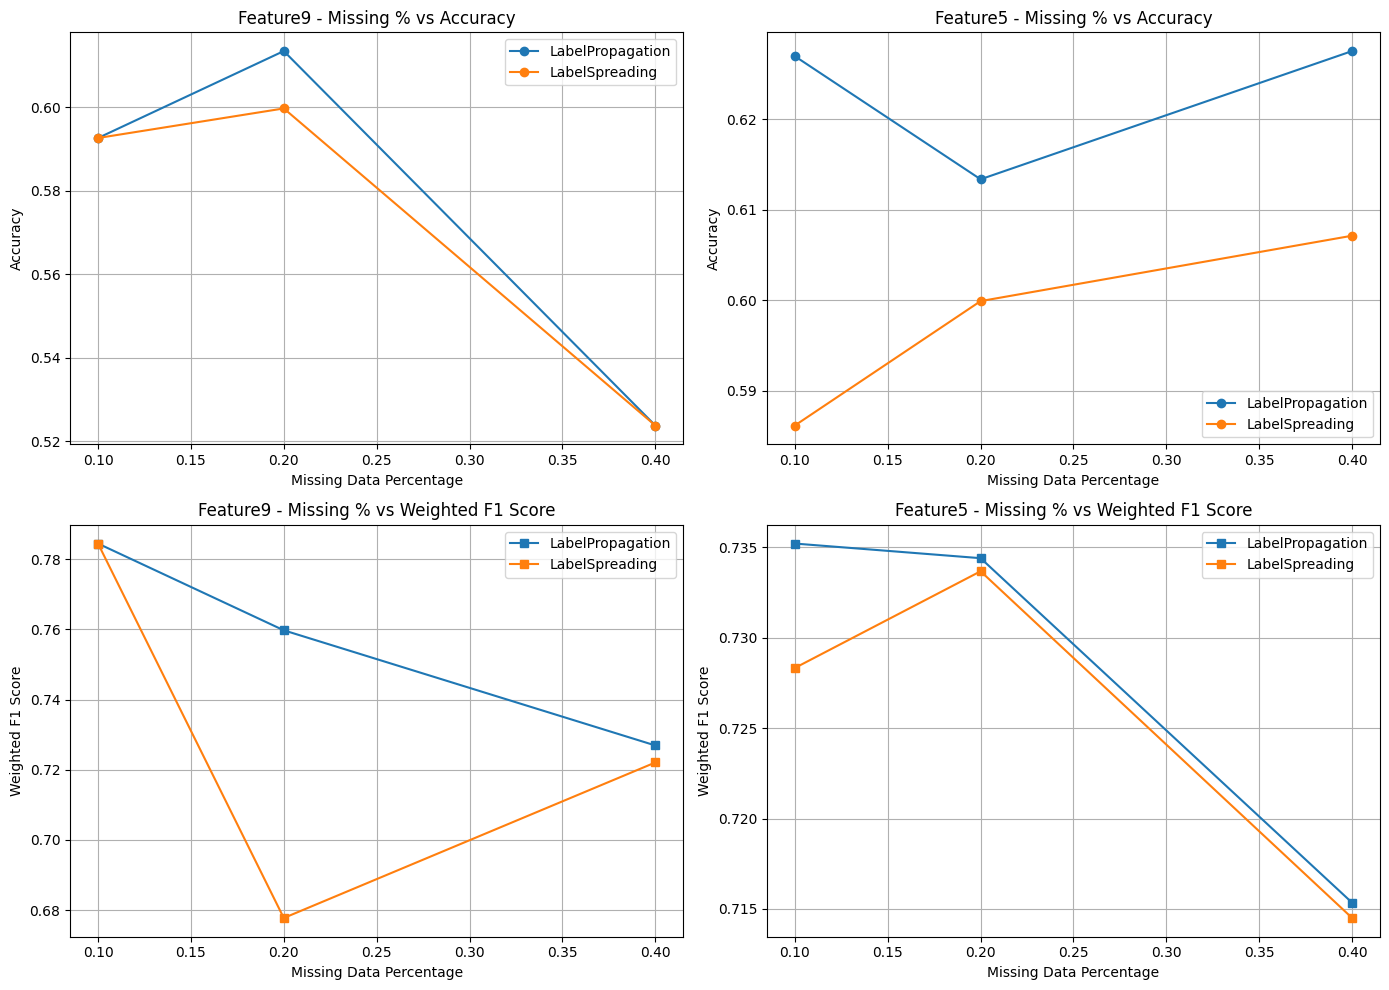

In [33]:
plt.figure(figsize=(14, 10))

for idx, column in enumerate(missing_columns, start=1):
    # Plot Accuracy vs Missing Percentage for this column.
    plt.subplot(2, len(missing_columns), idx)
    for model_type in ['LabelPropagation', 'LabelSpreading']:
        subset = missing_results_df[(missing_results_df['Model'] == model_type) & 
                                    (missing_results_df['Missing Column'] == column)]
        plt.plot(subset['Missing %'], subset['Best Accuracy'], marker='o', label=f"{model_type}")
    plt.title(f'{column} - Missing % vs Accuracy')
    plt.xlabel('Missing Data Percentage')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    
    # Plot Weighted F1 Score vs Missing Percentage for this column.
    plt.subplot(2, len(missing_columns), len(missing_columns) + idx)
    for model_type in ['LabelPropagation', 'LabelSpreading']:
        subset = missing_results_df[(missing_results_df['Model'] == model_type) & 
                                    (missing_results_df['Missing Column'] == column)]
        plt.plot(subset['Missing %'], subset['Weighted F1 Score'], marker='s', label=f"{model_type}")
    plt.title(f'{column} - Missing % vs Weighted F1 Score')
    plt.xlabel('Missing Data Percentage')
    plt.ylabel('Weighted F1 Score')
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()